## Mooring Report, Lake Zug, 2026.04.09

All moorings retreived.

In [24]:
# imports
import ewgreaders as ewg
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
lake = 'Zug'
year = '2026'
date = '20260409'

### LZC

In [77]:
location = 'LZC'

In [78]:
mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
adcps = mreader.get_adcps()
thermistors = mreader.get_thermistors()
oxygen_loggers = mreader.get_oxygen_loggers()

#### ADCPs

#### Thermistors

In [82]:
ds_chain = []
for t in thermistors:
    try:
        treader = ewg.thermistor_reader.ThermistorReader(t['serial_id'], lake, location, year, date)
        ds = treader.load_from_L0()
        ds = ds.sel(time=slice(t_start, t_end))
        ds_chain.append(ds)
    except FileNotFoundError:
        continue

ds_temp = mreader.create_instrument_chain(ds_chain)

IndexError: Could not find single data file for 200566.

#### Oxygen loggers

In [79]:
ds_chain = []
for ol in oxygen_loggers:

    try:
        oreader = ewg.o2_reader.O2Reader(ol['serial_id'], lake, location, year, date)
        ds = oreader.load_from_L0()
        ds = ds.sel(time=slice(t_start, t_end))
        ds_chain.append(ds)
    except FileNotFoundError:
        continue

ds_do = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


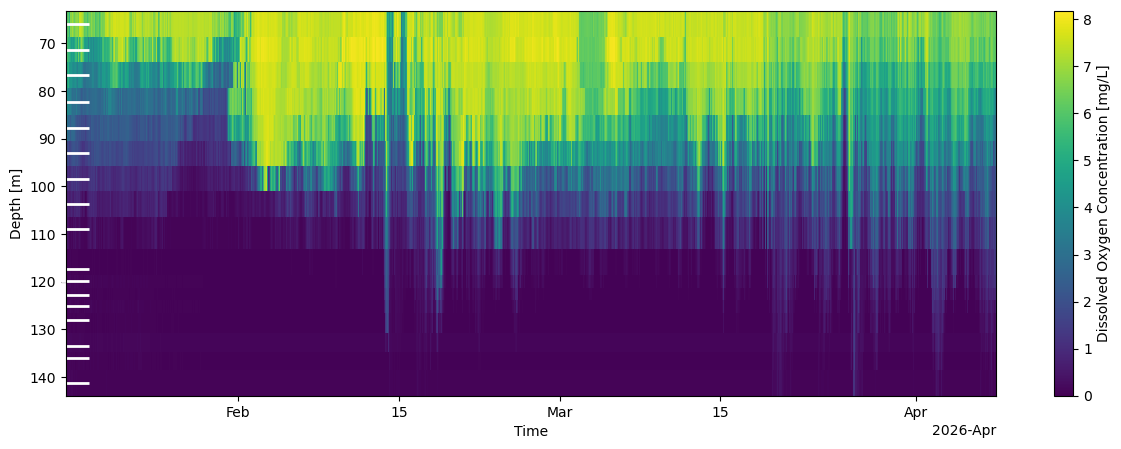

In [80]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, ax=ax)
for d in ds_do.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Dissolved Oxygen Concentration [mg/L]")

ax.invert_yaxis()
plt.show()

### LZW

In [18]:
location = 'LZW'

In [19]:
mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
adcps = mreader.get_adcps()
thermistors = mreader.get_thermistors()
oxygen_loggers = mreader.get_oxygen_loggers()

#### ADCP

In [21]:
adcp = adcps[0]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)

In [22]:
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(time=slice(t_start, t_end))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZW/L0\3U16576.000 ...


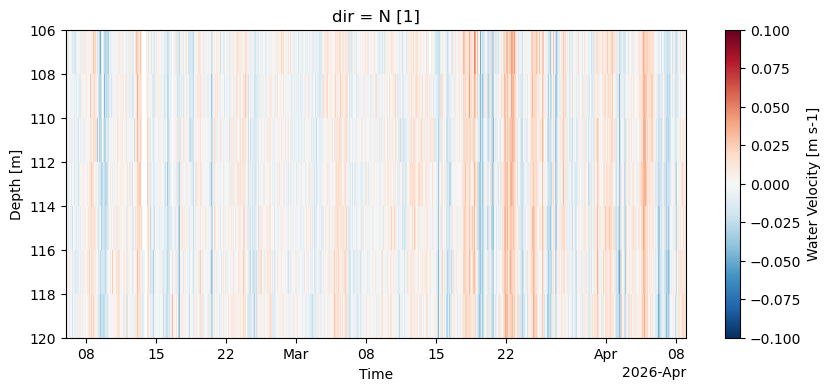

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))

ds.vel.sel(dir='N').plot(cmap='RdBu_r', vmin=-0.1, vmax=0.1, ax=ax)

ax.set_xlabel('Time')
ax.set_ylabel('Depth [m]')
ax.invert_yaxis()
plt.show()

#### Thermistors

In [48]:
ds_chain = []
for t in thermistors:
    if t['serial_id'] != '82133':  # time dimension does not align
        treader = ewg.thermistor_reader.ThermistorReader(t['serial_id'], lake, location, year, date)
        ds = treader.load_from_L0()
        ds = ds.sel(time=slice(t_start, t_end))
        ds_chain.append(ds)

ds_temp = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


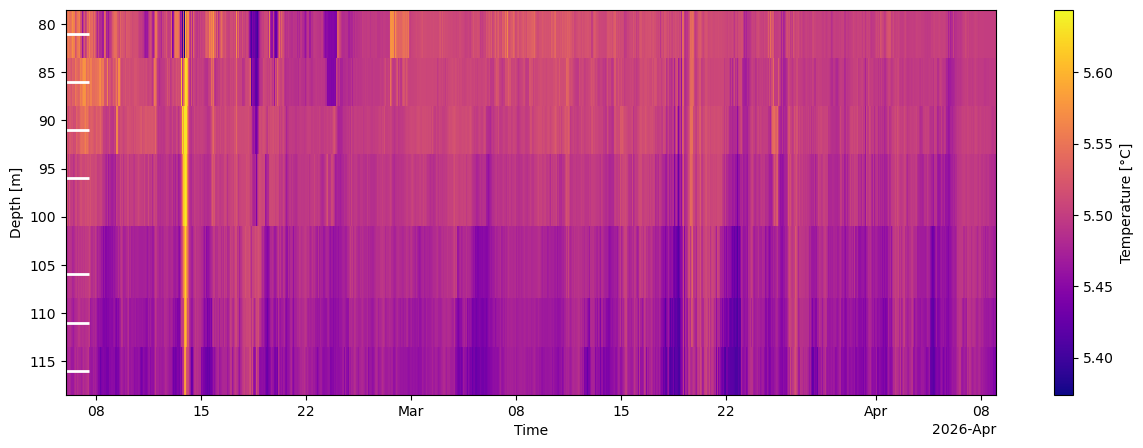

In [49]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_temp.temp.plot(cmap='plasma', ax=ax)
for d in ds_temp.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Temperature [°C]")

ax.invert_yaxis()
plt.show()

#### Oxygen loggers

In [53]:
ds_chain = []
for ol in oxygen_loggers:
    serial_id = ol['serial_id']

    oreader = ewg.o2_reader.O2Reader(ol['serial_id'], lake, location, year, date)
    ds = oreader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    ds_chain.append(ds)

ds_do = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


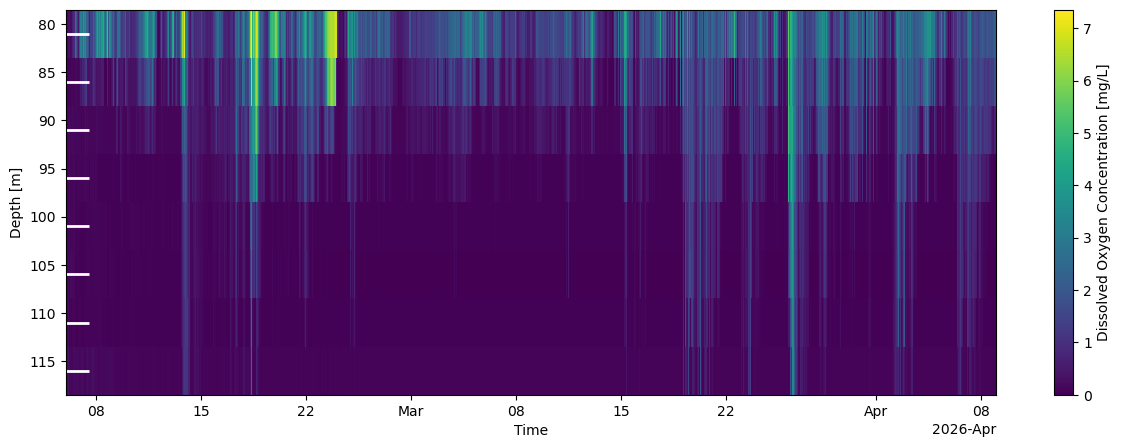

In [54]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, ax=ax)
for d in ds_do.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Dissolved Oxygen Concentration [mg/L]")

ax.invert_yaxis()
plt.show()

### LZE

In [74]:
location = 'LZE'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
adcps = mreader.get_adcps()
thermistors = mreader.get_thermistors()
oxygen_loggers = mreader.get_oxygen_loggers()

#### ADCP

In [57]:
adcp = adcps[0]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(time=slice(t_start, t_end))
ds.depth.mean()


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZE/L0\6U23656.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')


<xarray.DataArray 'depth' ()> Size: 8B
array(120.)

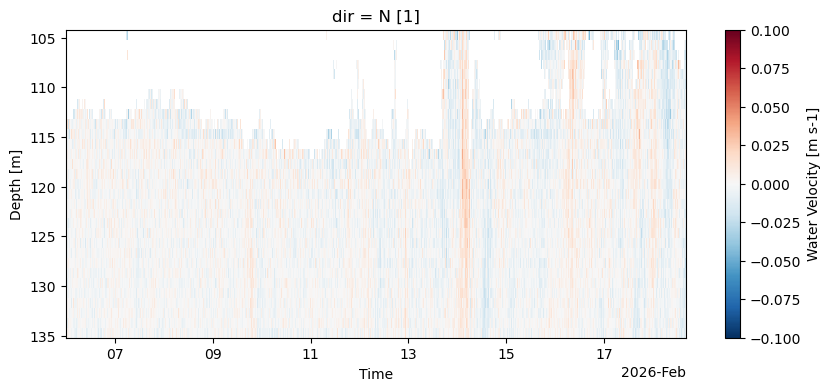

In [58]:
fig, ax = plt.subplots(figsize=(10, 4))

ds.vel.sel(dir='N').plot(cmap='RdBu_r', vmin=-0.1, vmax=0.1, ax=ax)

ax.set_xlabel('Time')
ax.set_ylabel('Depth [m]')
ax.invert_yaxis()
plt.show()

#### Thermistors

In [62]:
ds_chain = []
for t in thermistors:
    treader = ewg.thermistor_reader.ThermistorReader(t['serial_id'], lake, location, year, date)
    ds = treader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    ds_chain.append(ds)

ds_temp = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


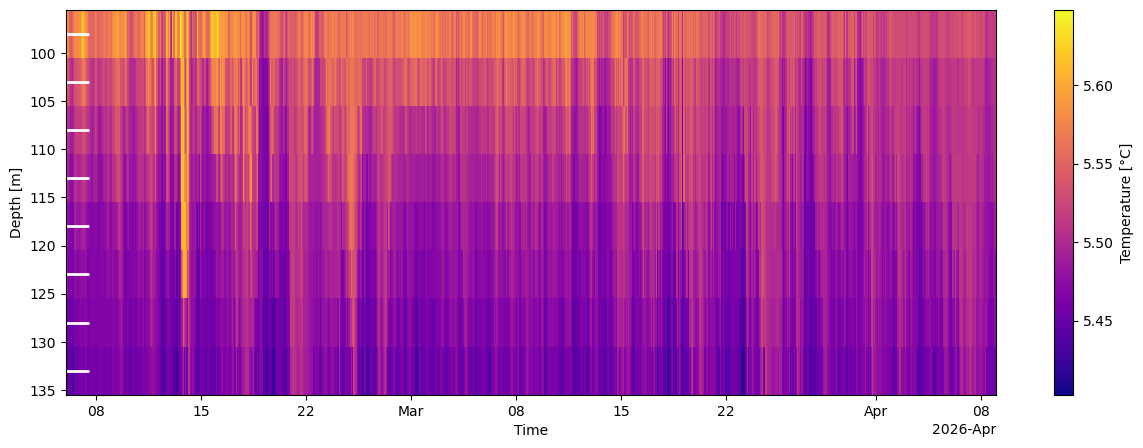

In [63]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_temp.temp.plot(cmap='plasma', ax=ax)
for d in ds_temp.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Temperature [°C]")

ax.invert_yaxis()
plt.show()

#### Oxygen loggers

In [75]:
ds_chain = []
for ol in oxygen_loggers:
    if ol['serial_id'] != '246068':
        oreader = ewg.o2_reader.O2Reader(ol['serial_id'], lake, location, year, date)
        ds = oreader.load_from_L0()
        ds = ds.sel(time=slice(t_start, t_end))
        ds_chain.append(ds)

ds_do = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


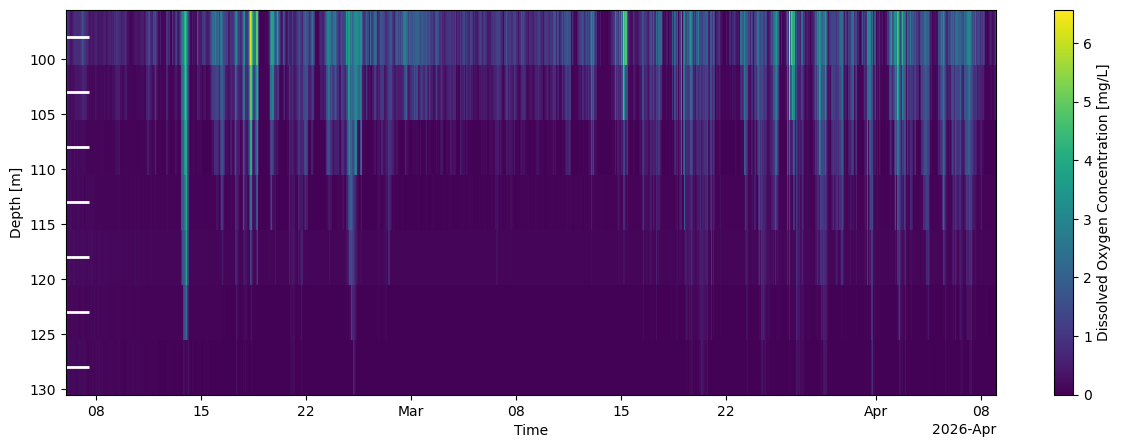

In [76]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, ax=ax)
for d in ds_do.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Dissolved Oxygen Concentration [mg/L]")

ax.invert_yaxis()
plt.show()

### LZN

In [64]:
location = 'LZN'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
adcps = mreader.get_adcps()
thermistors = mreader.get_thermistors()
oxygen_loggers = mreader.get_oxygen_loggers()

#### ADCP

In [66]:
adcp = adcps[0]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(time=slice(t_start, t_end))
ds.depth.mean()


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZN/L0\3U420.000 ...


<xarray.DataArray 'depth' ()> Size: 8B
array(133.01399231)

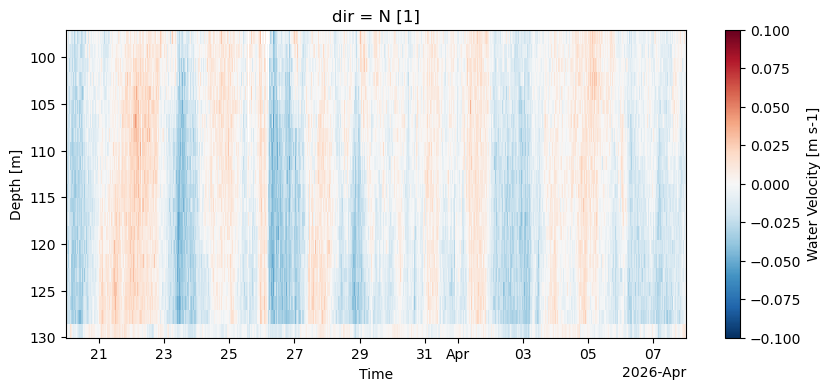

In [67]:
fig, ax = plt.subplots(figsize=(10, 4))

ds.vel.sel(dir='N').plot(cmap='RdBu_r', vmin=-0.1, vmax=0.1, ax=ax)

ax.set_xlabel('Time')
ax.set_ylabel('Depth [m]')
ax.invert_yaxis()
plt.show()

#### Thermistors

In [69]:
ds_chain = []
for t in thermistors:
    treader = ewg.thermistor_reader.ThermistorReader(t['serial_id'], lake, location, year, date)
    ds = treader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    ds_chain.append(ds)

ds_temp = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


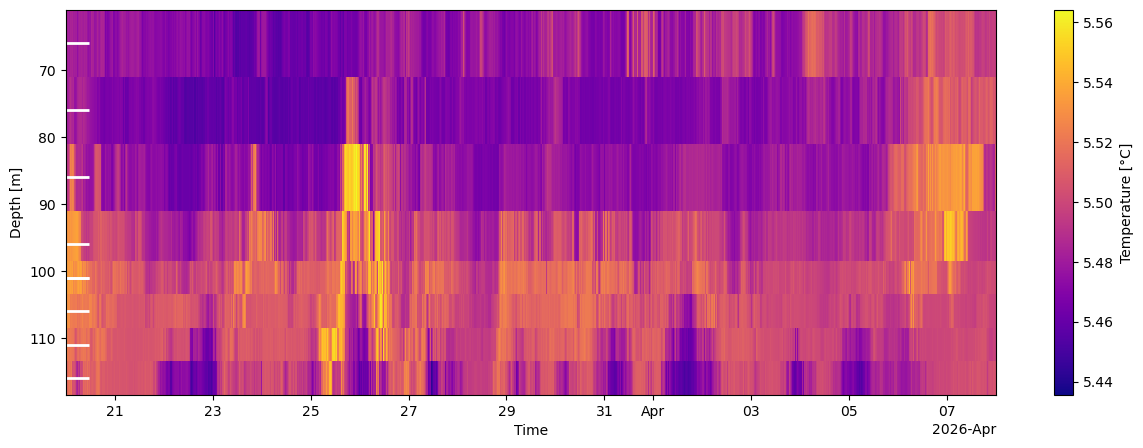

In [70]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_temp.temp.plot(cmap='plasma', ax=ax)
for d in ds_temp.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Temperature [°C]")

ax.invert_yaxis()
plt.show()

#### Oxygen loggers

In [71]:
ds_chain = []
for ol in oxygen_loggers:
    if ol['serial_id'] != '246068':
        oreader = ewg.o2_reader.O2Reader(ol['serial_id'], lake, location, year, date)
        ds = oreader.load_from_L0()
        ds = ds.sel(time=slice(t_start, t_end))
        ds_chain.append(ds)

ds_do = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


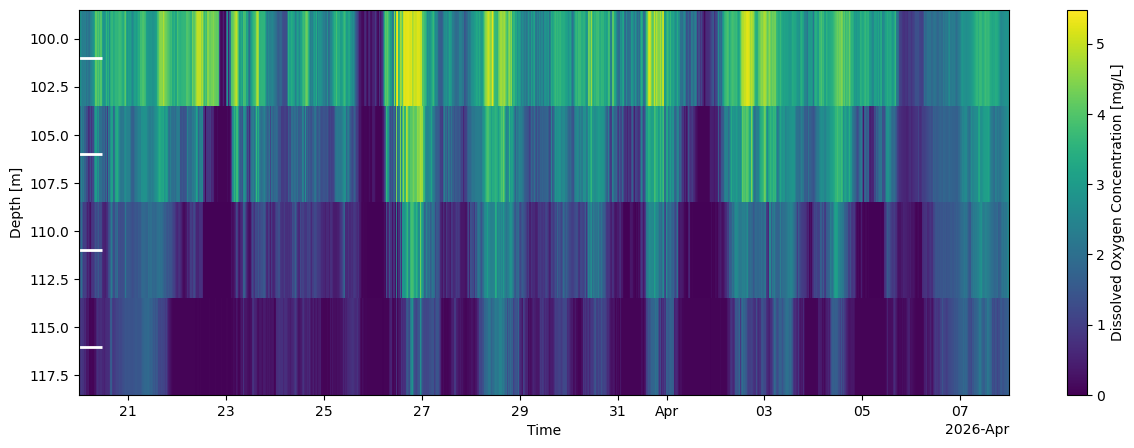

In [72]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, ax=ax)
for d in ds_do.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Dissolved Oxygen Concentration [mg/L]")

ax.invert_yaxis()
plt.show()